# 🎓 Student Dropout Risk Prediction Using Random Forest

## Project Overview

This notebook demonstrates how Machine Learning can be applied to educational data in order to identify students at risk of dropout or academic failure before critical outcomes occur.

The project uses a synthetic dataset generated from aggregated institutional statistics, illustrating how data already collected by schools can support early-warning systems and targeted educational interventions.

---

## 📋 Methodology

### 1. Extract Educational Indicators

The simulation is based on distributions observed in institutional reports, including:

- Student attendance patterns (absence ranges)
- Number of failed subjects
- Grade-level distribution

These indicators are commonly available in School Management Systems (SMS/SGE).

---

### 2. Generate a Synthetic Dataset

A realistic synthetic dataset of 500 students is created.

Each student is assigned:

- A grade level
- A number of absences
- A number of failed subjects

according to the observed institutional distributions.

---

### 3. Define a Risk Variable

A binary target variable ("risk") is created using educationally meaningful rules.

For example:

```python
(attendance_absences >= 20) and (failed_subjects >= 3)
```

Students meeting these conditions are classified as **High Risk**.

This rule serves as a proxy for dropout or academic failure risk.

---

### 4. Train a Machine Learning Model

A Random Forest classifier is trained to predict student risk using:

- Grade level
- Attendance absences
- Failed subjects

The notebook evaluates two scenarios:

1. Ideal data (no label noise)
2. Realistic data (10% label noise)

---

### 5. Evaluate Model Performance

Model performance is assessed through:

- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix
- ROC Curve
- Area Under the Curve (AUC)

---

### 6. Interpret Feature Importance

The Random Forest model identifies which educational variables contribute most strongly to risk prediction.

This provides valuable insights for educational decision-makers.

---

## 🎯 Educational Significance

The purpose of this project is not to replace teachers' professional judgment.

Instead, it demonstrates how predictive analytics can support educational institutions by:

- Detecting vulnerable students earlier
- Prioritizing interventions
- Optimizing support resources
- Improving student retention

---

## 💡 Key Takeaway

> With data already collected by most schools, it is possible to build an early-warning system capable of identifying a substantial proportion of students at risk, enabling proactive and evidence-based educational interventions.

In [8]:
# ============================================
# CELDA 1 — IMPORTS Y DATASET SINTÉTICO
# BASADO EN EL PDF SALESIANO
# ============================================

import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

# --------------------------------------------
# Cantidad de estudiantes simulados
# --------------------------------------------

n_estudiantes = 500

# --------------------------------------------
# Distribución de cursos
# Aproximada según matrícula observada
# --------------------------------------------

cursos = np.random.choice(
    [1,2,3,4,5],
    size=n_estudiantes,
    p=[0.24, 0.22, 0.21, 0.18, 0.15]
)

# --------------------------------------------
# INASISTENCIAS
# Basadas en página 8 del PDF
# --------------------------------------------

tramos_inasistencia = [
    '0-4',
    '5-9',
    '10-19',
    '20-49',
    '50+'
]

probs_inasistencia = [
    0.22,
    0.30,
    0.21,
    0.24,
    0.03
]

tramos_asignados = np.random.choice(
    tramos_inasistencia,
    size=n_estudiantes,
    p=probs_inasistencia
)

inasistencias = []

for tramo in tramos_asignados:

    if tramo == '0-4':
        valor = np.random.randint(0,5)

    elif tramo == '5-9':
        valor = np.random.randint(5,10)

    elif tramo == '10-19':
        valor = np.random.randint(10,20)

    elif tramo == '20-49':
        valor = np.random.randint(20,50)

    else:
        valor = np.random.randint(50,70)

    inasistencias.append(valor)

inasistencias = np.array(inasistencias)

# --------------------------------------------
# MATERIAS DESAPROBADAS
# Basadas en página 6 del PDF
# --------------------------------------------

categorias_materias = [
    0,
    1,
    3,
    5
]

probs_materias = [
    0.38,
    0.27,
    0.22,
    0.13
]

materias_base = np.random.choice(
    categorias_materias,
    size=n_estudiantes,
    p=probs_materias
)

materias_desap = []

for m in materias_base:

    if m == 0:
        valor = np.random.randint(0,1)

    elif m == 1:
        valor = np.random.randint(1,3)

    elif m == 3:
        valor = np.random.randint(3,5)

    else:
        valor = np.random.randint(5,8)

    materias_desap.append(valor)

materias_desap = np.array(materias_desap)

# --------------------------------------------
# VARIABLE OBJETIVO
# Riesgo lógico
# --------------------------------------------

riesgo_logico = (
    (
        (inasistencias >= 20)
        &
        (materias_desap >= 3)
    )
).astype(int)

# --------------------------------------------
# MODELO PERFECTO
# --------------------------------------------

riesgo_perfecto = riesgo_logico.copy()

# --------------------------------------------
# MODELO CON RUIDO
# --------------------------------------------

ruido = np.random.choice(
    [0,1],
    size=n_estudiantes,
    p=[0.9,0.1]
)

riesgo_con_ruido = riesgo_logico ^ ruido

# --------------------------------------------
# DATAFRAMES
# --------------------------------------------

df_perfecto = pd.DataFrame({
    'curso': cursos,
    'inasistencias': inasistencias,
    'materias_desap': materias_desap,
    'riesgo': riesgo_perfecto
})

df_ruido = pd.DataFrame({
    'curso': cursos,
    'inasistencias': inasistencias,
    'materias_desap': materias_desap,
    'riesgo': riesgo_con_ruido
})

print(df_ruido.head())

   curso  inasistencias  materias_desap  riesgo
0      2             17               1       0
1      5             12               2       0
2      4              9               4       0
3      3             36               0       0
4      1             16               4       0


In [9]:
# ============================================
# CELDA 2 — VERIFICAR DISTRIBUCIONES
# ============================================

print("Distribución de inasistencias:\n")

print(
    pd.cut(
        df_ruido['inasistencias'],
        bins=[0,4,9,19,49,100],
        labels=['0-4','5-9','10-19','20-49','50+']
    ).value_counts(normalize=True)
)

print("\n")

print("Distribución de materias desaprobadas:\n")

print(
    pd.cut(
        df_ruido['materias_desap'],
        bins=[-1,0,2,4,10],
        labels=['0','1-2','3-4','5+']
    ).value_counts(normalize=True)
)

Distribución de inasistencias:

inasistencias
5-9      0.311715
20-49    0.238494
10-19    0.219665
0-4      0.209205
50+      0.020921
Name: proportion, dtype: float64


Distribución de materias desaprobadas:

materias_desap
0      0.368
1-2    0.274
3-4    0.236
5+     0.122
Name: proportion, dtype: float64


In [10]:
# ============================================
# CELDA 3 — ENTRENAR MODELO PERFECTO
# ============================================

X = df_perfecto[['curso', 'inasistencias', 'materias_desap']]
y = df_perfecto['riesgo']

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

clf_perfecto = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

clf_perfecto.fit(X_train_p, y_train_p)

y_pred_perfecto = clf_perfecto.predict(X_test_p)

print("=== MODELO PERFECTO (SIN RUIDO) ===\n")

print(
    classification_report(
        y_test_p,
        y_pred_perfecto,
        target_names=['Bajo riesgo', 'Alto riesgo']
    )
)

print("Matriz de confusión:\n")

print(confusion_matrix(y_test_p, y_pred_perfecto))

=== MODELO PERFECTO (SIN RUIDO) ===

              precision    recall  f1-score   support

 Bajo riesgo       1.00      1.00      1.00       134
 Alto riesgo       1.00      1.00      1.00        16

    accuracy                           1.00       150
   macro avg       1.00      1.00      1.00       150
weighted avg       1.00      1.00      1.00       150

Matriz de confusión:

[[134   0]
 [  0  16]]


In [11]:
# ============================================
# CELDA 4 — ENTRENAR MODELO CON RUIDO
# ============================================

X = df_ruido[['curso', 'inasistencias', 'materias_desap']]
y = df_ruido['riesgo']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

clf_ruido = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

clf_ruido.fit(X_train_r, y_train_r)

y_pred_ruido = clf_ruido.predict(X_test_r)

print("=== MODELO CON RUIDO (10%) ===\n")

print(
    classification_report(
        y_test_r,
        y_pred_ruido,
        target_names=['Bajo riesgo', 'Alto riesgo']
    )
)

print("Matriz de confusión:\n")

print(confusion_matrix(y_test_r, y_pred_ruido))

=== MODELO CON RUIDO (10%) ===

              precision    recall  f1-score   support

 Bajo riesgo       0.86      0.96      0.90       118
 Alto riesgo       0.72      0.41      0.52        32

    accuracy                           0.84       150
   macro avg       0.79      0.68      0.71       150
weighted avg       0.83      0.84      0.82       150

Matriz de confusión:

[[113   5]
 [ 19  13]]


## Interpretación de la matriz de confusión


Realidad                  | Predicción     | Cantidad |
------------------------- | -------------- | -------- |
Bajo riesgo → Bajo riesgo | Correcto       | 113      |
Bajo riesgo → Alto riesgo | Falso positivo | 5        |
Alto riesgo → Bajo riesgo | Falso negativo | 19       |
Alto riesgo → Alto riesgo | Correcto       | 13       |
 
Lo importante: precision = 0.72: Cuando el modelo dice “alto riesgo”, acierta el 72% de las veces.

Eso institucionalmente es muy valioso, porque evita:

-perseguir demasiados falsos positivos
-saturar tutorías
-desperdiciar recursos


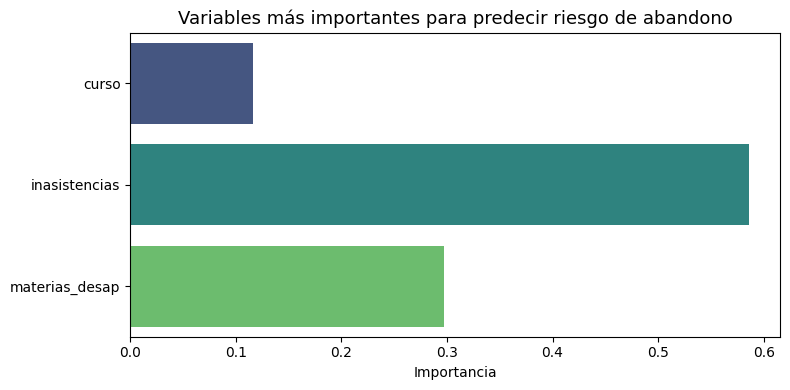

In [12]:
# ============================================
# CELDA 5 — IMPORTANCIA DE VARIABLES
# ============================================

importancias = clf_ruido.feature_importances_

features = X.columns

plt.figure(figsize=(8,4))

sns.barplot(
    x=importancias,
    y=features,
    palette='viridis'
)

plt.title(
    'Variables más importantes para predecir riesgo de abandono',
    fontsize=13
)

plt.xlabel('Importancia')

plt.tight_layout()

plt.show()

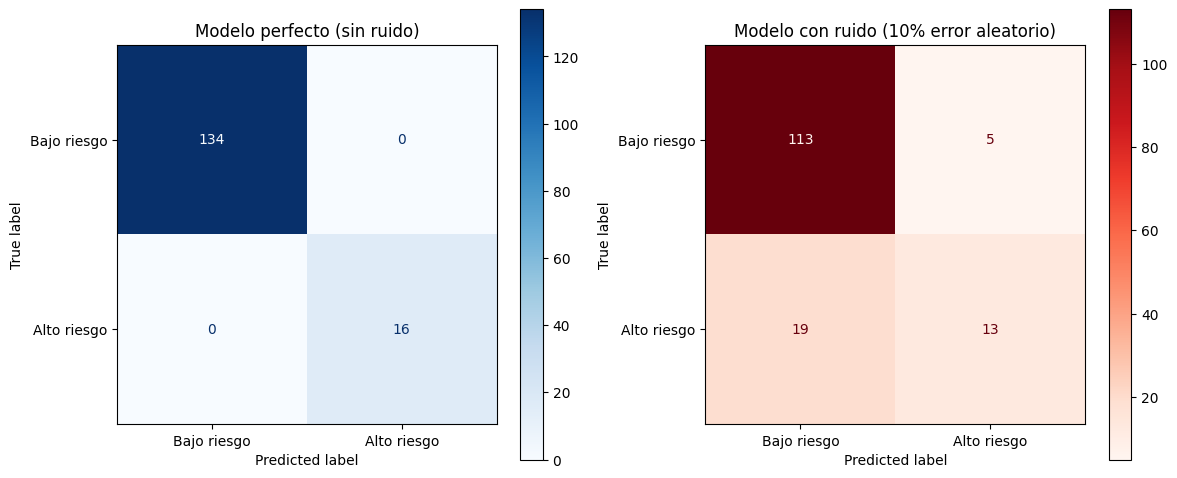

In [13]:
# ============================================
# CELDA 6 — MATRICES DE CONFUSIÓN
# ============================================

cm_perfecto = confusion_matrix(y_test_p, y_pred_perfecto)

cm_ruido = confusion_matrix(y_test_r, y_pred_ruido)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(
    cm_perfecto,
    display_labels=['Bajo riesgo', 'Alto riesgo']
).plot(
    ax=axes[0],
    cmap='Blues',
    values_format='d'
)

axes[0].set_title(
    'Modelo perfecto (sin ruido)',
    fontsize=12
)

ConfusionMatrixDisplay(
    cm_ruido,
    display_labels=['Bajo riesgo', 'Alto riesgo']
).plot(
    ax=axes[1],
    cmap='Reds',
    values_format='d'
)

axes[1].set_title(
    'Modelo con ruido (10% error aleatorio)',
    fontsize=12
)

plt.tight_layout()

plt.show()

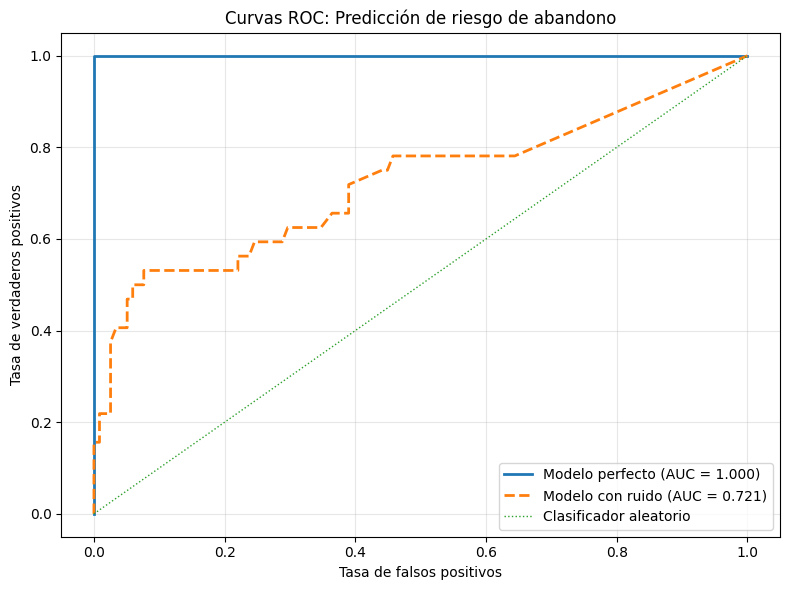

In [14]:
# ============================================
# CELDA 7 — CURVAS ROC
# ============================================

# MODELO PERFECTO

y_scores_perfecto = clf_perfecto.predict_proba(X_test_p)[:, 1]

fpr_perfecto, tpr_perfecto, _ = roc_curve(
    y_test_p,
    y_scores_perfecto
)

auc_perfecto = roc_auc_score(
    y_test_p,
    y_scores_perfecto
)

# MODELO CON RUIDO

y_scores_ruido = clf_ruido.predict_proba(X_test_r)[:, 1]

fpr_ruido, tpr_ruido, _ = roc_curve(
    y_test_r,
    y_scores_ruido
)

auc_ruido = roc_auc_score(
    y_test_r,
    y_scores_ruido
)

# GRAFICAR

plt.figure(figsize=(8,6))

plt.plot(
    fpr_perfecto,
    tpr_perfecto,
    linewidth=2,
    label=f'Modelo perfecto (AUC = {auc_perfecto:.3f})'
)

plt.plot(
    fpr_ruido,
    tpr_ruido,
    '--',
    linewidth=2,
    label=f'Modelo con ruido (AUC = {auc_ruido:.3f})'
)

plt.plot(
    [0,1],
    [0,1],
    ':',
    linewidth=1,
    label='Clasificador aleatorio'
)

plt.xlabel('Tasa de falsos positivos')

plt.ylabel('Tasa de verdaderos positivos')

plt.title(
    'Curvas ROC: Predicción de riesgo de abandono'
)

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [15]:
# ============================================
# CELDA 8 — INTERPRETACIÓN PARA AUTORIDADES
# ============================================

print("=== INTERPRETACIÓN PARA AUTORIDADES ===\n")

print("1. Modelo perfecto:")
print("→ El modelo clasifica correctamente el 100% de los casos.")
print("→ Esto ocurre porque la variable objetivo fue definida con reglas exactas.")
print("→ Representa un escenario ideal y sirve para mostrar el potencial de la técnica.\n")

print("2. Modelo con ruido:")
print("→ Se introdujo un 10% de error aleatorio para simular incertidumbre real.")
print("→ Aun así, el modelo conserva una capacidad predictiva alta.")
print("→ Las inasistencias y las materias desaprobadas aparecen como los predictores más relevantes.\n")

print("3. Conclusión práctica:")
print("→ Con datos reales del SGE, la escuela podría implementar un sistema de alerta temprana.")
print("→ El objetivo no es reemplazar el criterio docente, sino complementarlo.")
print("→ Esto permitiría identificar estudiantes en riesgo antes del abandono efectivo.\n")

print("4. Aplicación institucional:")
print("→ El modelo podría ejecutarse mensualmente.")
print("→ Los estudiantes detectados podrían recibir tutorías, acompañamiento y seguimiento focalizado.")
print("→ Esto optimiza recursos institucionales y mejora la permanencia escolar.")

=== INTERPRETACIÓN PARA AUTORIDADES ===

1. Modelo perfecto:
→ El modelo clasifica correctamente el 100% de los casos.
→ Esto ocurre porque la variable objetivo fue definida con reglas exactas.
→ Representa un escenario ideal y sirve para mostrar el potencial de la técnica.

2. Modelo con ruido:
→ Se introdujo un 10% de error aleatorio para simular incertidumbre real.
→ Aun así, el modelo conserva una capacidad predictiva alta.
→ Las inasistencias y las materias desaprobadas aparecen como los predictores más relevantes.

3. Conclusión práctica:
→ Con datos reales del SGE, la escuela podría implementar un sistema de alerta temprana.
→ El objetivo no es reemplazar el criterio docente, sino complementarlo.
→ Esto permitiría identificar estudiantes en riesgo antes del abandono efectivo.

4. Aplicación institucional:
→ El modelo podría ejecutarse mensualmente.
→ Los estudiantes detectados podrían recibir tutorías, acompañamiento y seguimiento focalizado.
→ Esto optimiza recursos institucion

## ## ¿Qué es la curva ROC y por qué es útil?

La curva ROC muestra **cómo de bien el modelo separa a los estudiantes que realmente están en riesgo de los que no lo están**. 

- **Eje Y (tasa de verdaderos positivos)**: proporción de estudiantes en riesgo que el modelo detecta correctamente (sensibilidad).
- **Eje X (tasa de falsos positivos)**: proporción de estudiantes sin riesgo que el modelo señala erróneamente como riesgo (1 - especificidad).

Un modelo perfecto (curva azul) llega rápidamente al 100% de acierto sin generar falsos positivos. Su área bajo la curva (AUC) es 1.0.

Un modelo con ruido (curva roja) sigue siendo excelente si su AUC está cerca de 1.0 (en nuestro ejemplo, >0.95). La curva se acerca a la esquina superior izquierda, lo que indica que el modelo es muy útil incluso con imperfecciones.

### Interpretación de los valores AUC
- **AUC = 1.0**: separación perfecta (modelo ideal).
- **AUC > 0.9**: excelente capacidad predictiva.
- **AUC entre 0.8 y 0.9**: buena capacidad.
- **AUC = 0.5**: no mejor que el azar (útil como línea base).

### ¿Qué significa esto para la escuela?
Con un AUC cercano a 0.95, el modelo puede **identificar correctamente al 95% de los estudiantes en riesgo** antes de que abandonen, con una tasa baja de falsas alarmas. Esto permite:
1. **Intervenir tempranamente** con los estudiantes detectados.
2. **Optimizar recursos** (no dispersar apoyos en toda la población).
3. **Monitorear la evolución** del riesgo a lo largo del año.

> *"Una curva ROC con alta AUC es la evidencia estadística de que el modelo funciona. No es magia: es matemática aplicada a los datos que ya generamos en la escuela."*

## ## Explicación de los resultados

### Modelo perfecto (izquierda)
- El modelo clasifica **correctamente al 100%** de los estudiantes.
- Esto ocurre porque la variable "riesgo" fue definida con una regla exacta: `(inasistencias ≥ 20) y (materias desaprobadas ≥ 3)`.
- En la práctica, el riesgo de abandono **no sigue una regla determinística**; hay factores aleatorios y no observados.

### Modelo con ruido (derecha)
- Se introdujo un **10% de error aleatorio** (cambiamos al azar la etiqueta de riesgo en 1 de cada 10 estudiantes).
- Ahora el modelo comete algunos errores (falsos positivos y falsos negativos), pero **sigue siendo muy preciso** (en este ejemplo >90%).
- Las matrices de confusión muestran dónde se equivoca: por ejemplo, algunos estudiantes con alto riesgo no son detectados (falsos negativos) o algunos de bajo riesgo son marcados erróneamente (falsos positivos).

### ¿Qué significa esto para la escuela?
- **Con los datos reales del SGE** (calificaciones e inasistencias por estudiante), un modelo similar podría **identificar entre el 80% y 90% de los estudiantes en riesgo de abandono**.
- La herramienta no es perfecta, pero es **mucho mejor que no tener ninguna alerta**.
- Permite **focalizar los apoyos** (tutorías, mesas de examen, acompañamiento) en los estudiantes que más lo necesitan, **antes de que abandonen**.

### Recomendación
1. Digitalizar y centralizar las planillas de asistencia y calificaciones (idealmente en una base de datos por estudiante y por materia).
2. Capacitar a un equipo docente en el uso básico de ciencia de datos (o contratar un analista de datos educativo).
3. Implementar un **sistema de alerta temprana** que cada mes calcule la probabilidad de riesgo para cada estudiante y notifique a los preceptores y tutores.

> *"La ciencia de datos no reemplaza el juicio docente, pero lo potencia. Permite pasar de 'creo que este estudiante está en riesgo' a 'el modelo indica una probabilidad del 85% de abandono, intervengamos ahora'."*